<a href="https://colab.research.google.com/github/drskprabhakar/AI-ML-DL-colab-notebooks-coding-models/blob/main/dr_vs_no_dr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import os

In [3]:
os.listdir('/content/drive/MyDrive/Keerthana menon')

['NO DR', 'DR']

### Check the number of images in each class using

In [4]:
base_path = '/content/drive/MyDrive/Keerthana menon'

for folder in os.listdir(base_path):
    folder_path = os.path.join(base_path, folder)

    if os.path.isdir(folder_path):
        print(folder, ":", len(os.listdir(folder_path)), "images")

NO DR : 36 images
DR : 36 images


### See a few filenames:

In [5]:
for folder in os.listdir(base_path):
    folder_path = os.path.join(base_path, folder)

    if os.path.isdir(folder_path):
        print("\nClass:", folder)
        print(os.listdir(folder_path)[:5])


Class: NO DR
['8.Umamaheshwari prasanna.jpg', '5.Jayamma venkategowda.jpg', '654321_N_Rangaswamy_19760712_20191208_(77850).jpg', '12.Ragu Patel.jpg', '19.Gurusiddappa.jpg']

Class: DR
['22. Renuka.jpg', '17.Parameshwarappa.jpg', '5.Sundramma.jpg', '14.Venkatachala venkataramashetty.jpg', '2.Puttamma.jpg']


### CNN training with TensorFlow/Keras

### Adding augmentation to improve generalization:

In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    base_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_data = datagen.flow_from_directory(
    base_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 58 images belonging to 2 classes.
Found 14 images belonging to 2 classes.


In [7]:
print(train_data.class_indices)

{'DR': 0, 'NO DR': 1}


### Build a simple CNN model:

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    GlobalAveragePooling2D,
    Dense,
    Dropout
)

model = Sequential([

    Input(shape=(224,224,3)),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    GlobalAveragePooling2D(),

    Dense(64, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,569 (396.75 KB)

 Trainable params: 101,569 (396.75 KB)

 Non-trainable params: 0 (0.00 B)

###  Train the model:

In [9]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15
)
model.save('dr_cnn_classifier.keras')

Epoch 1/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 17s 9s/step - accuracy: 0.4483 - loss: 0.6966 - val_accuracy: 0.5000 - val_loss: 0.6954
Epoch 2/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step - accuracy: 0.5345 - loss: 0.6914 - val_accuracy: 0.5000 - val_loss: 0.6943
Epoch 3/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 4s/step - accuracy: 0.5517 - loss: 0.6886 - val_accuracy: 0.5000 - val_loss: 0.6941
Epoch 4/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 4s/step - accuracy: 0.5345 - loss: 0.6923 - val_accuracy: 0.5000 - val_loss: 0.6939
Epoch 5/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 5s/step - accuracy: 0.5000 - loss: 0.6963 - val_accuracy: 0.5000 - val_loss: 0.6936
Epoch 6/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 3s/step - accuracy: 0.5862 - loss: 0.6885 - val_accuracy: 0.5000 - val_loss: 0.6945
Epoch 7/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 18s 8s/step - accuracy: 0.5172 - loss: 0.7030 - val_accuracy: 0.5000 - val_loss: 0.6962
Epoch 8/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 12s 4s/step - accuracy: 0.4828 - loss: 0.6879 - val_accuracy: 0.5000 - val_loss: 0.6952
Epoch 9/15

### Plot accuracy

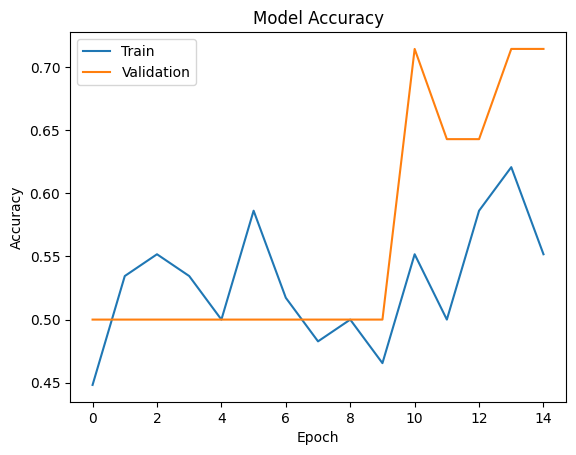

In [10]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

### Loss

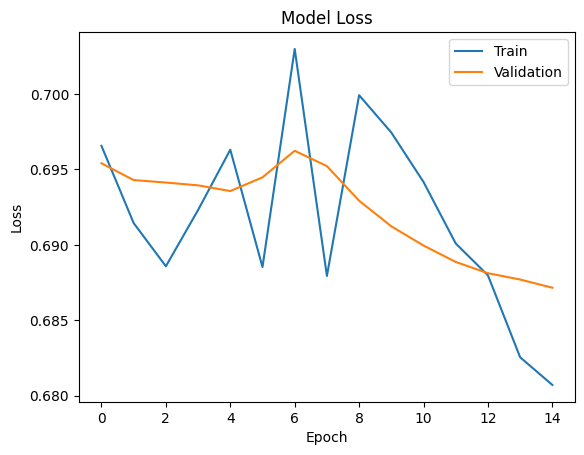

In [11]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

### Confusion matrix

In [30]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

pred = model.predict(val_data)

pred_classes = (pred > 0.5).astype(int)

true_classes = val_data.classes

print(confusion_matrix(true_classes, pred_classes))

print(classification_report(true_classes, pred_classes))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 808ms/step
[[7 0]
 [4 3]]
              precision    recall  f1-score   support

           0       0.64      1.00      0.78         7
           1       1.00      0.43      0.60         7

    accuracy                           0.71        14
   macro avg       0.82      0.71      0.69        14
weighted avg       0.82      0.71      0.69        14



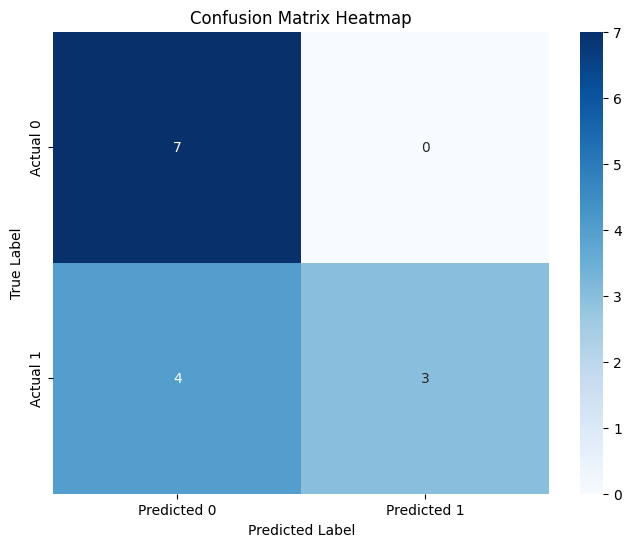

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap')
plt.show()

### AUC-ROC Curve

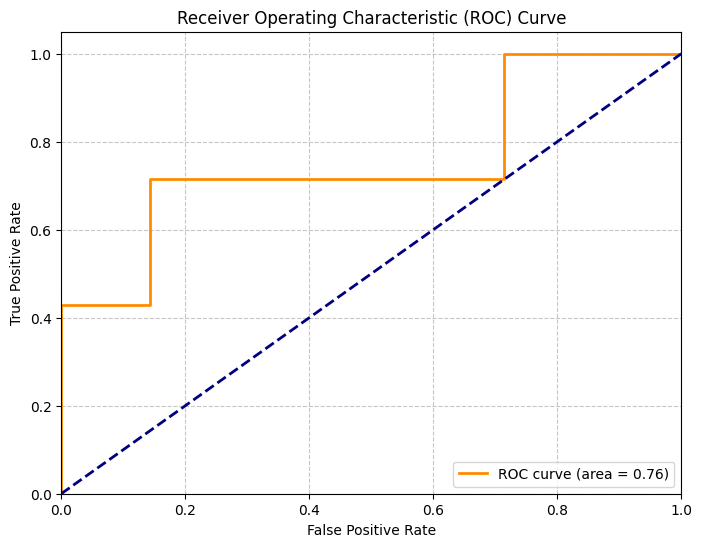

In [32]:
from sklearn.metrics import roc_curve, auc

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(true_classes, pred)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Precision-Recall Curve

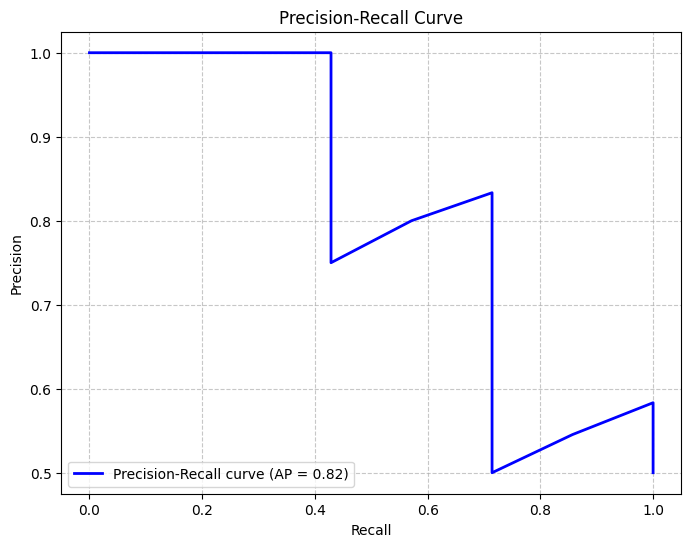

In [33]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Calculate Precision-Recall curve and Average Precision Score
precision, recall, _ = precision_recall_curve(true_classes, pred)
avg_precision = average_precision_score(true_classes, pred)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', lw=2, label=f'Precision-Recall curve (AP = {avg_precision:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
[[0.4685594]]
DR


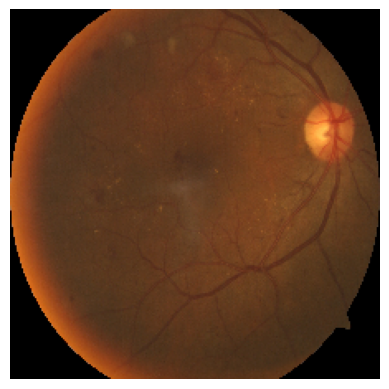

In [52]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = '/content/drive/MyDrive/Keerthana menon/DR/1.Mahadevamma shivanna.jpg'
img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)

img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

print(prediction)

if prediction > 0.5:
    print("NO DR")
else:
    print("DR")

plt.imshow(img)
plt.axis('off')
plt.show()

In [35]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

from tensorflow.keras.preprocessing import image

In [37]:
img_path = '/content/drive/MyDrive/Keerthana menon/DR/1.Mahadevamma shivanna.jpg'

In [38]:
img = image.load_img(img_path, target_size=(224,224))

img_array = image.img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)

img_array = img_array / 255.0

In [47]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):

    # Ensure the model has been built by calling it with an input
    _ = model(img_array)

    # Get the symbolic input tensor of the model
    grad_model_inputs = model.inputs[0] # Changed from model.input

    # Get the symbolic output tensor of the last convolutional layer
    conv_layer_output = model.get_layer(last_conv_layer_name).output

    # Get the symbolic output tensor of the entire model from its last layer
    model_prediction_output = model.layers[-1].output

    grad_model = tf.keras.models.Model(
        inputs=grad_model_inputs,
        outputs=[conv_layer_output, model_prediction_output]
    )

    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(img_array)

        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]

    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)

    return heatmap.numpy()

In [48]:
last_conv_layer_name = 'conv2d_2'
heatmap = make_gradcam_heatmap(
    img_array,
    model,
    last_conv_layer_name
)

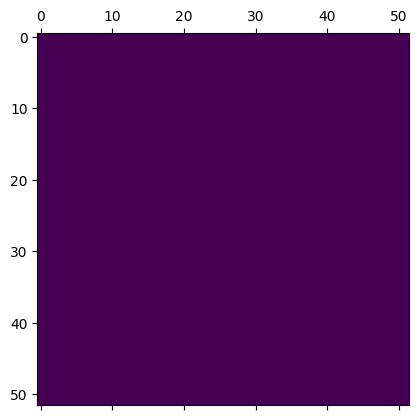

In [49]:
plt.matshow(heatmap)
plt.show()

### Overlay on retinal image

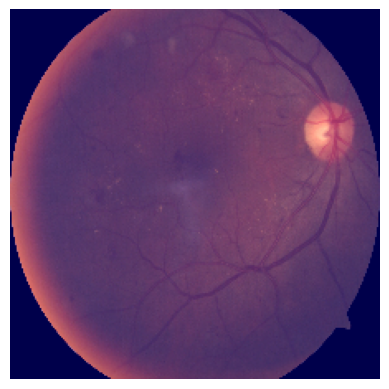

In [51]:
img = cv2.imread(img_path)

img = cv2.resize(img, (224,224))

heatmap = np.uint8(255 * heatmap)

heatmap = cv2.applyColorMap(
    heatmap,
    cv2.COLORMAP_JET
)

# Resize heatmap to match the image dimensions
heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))

superimposed_img = heatmap * 0.4 + img

cv2.imwrite('/content/gradcam.jpg', superimposed_img)

plt.imshow(cv2.cvtColor(
    np.uint8(superimposed_img),
    cv2.COLOR_BGR2RGB
))
plt.axis('off')
plt.show()

### Test on a single image